In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score , roc_curve)

print("Libraries loaded. Ready to build the Binary Classifier.")

Libraries loaded. Ready to build the Binary Classifier.


In [3]:
# Load the dataset
df = pd.read_csv("data.csv")

# --- DATA CLEANING ---
print("Initial row count:", len(df))

# 1. Handle missing values (Refer to eBook Chapter 2, Page 69)
if df.isnull().values.any():
    print(f"Dropping {df.isnull().sum().sum()} missing values...")
    df = df.dropna()

# 2. Remove duplicates
df = df.drop_duplicates()
print("Cleaned row count:", len(df))

# 3. Binary Conversion: 'Low' -> 0 (Safe), 'Medium'/'High' -> 1 (At Risk)
df['Binary_Risk'] = df['Risk_Category'].apply(lambda x: 0 if x == 'Low' else 1)

print("\nBinary Class Distribution:")
print(df['Binary_Risk'].value_counts())

Initial row count: 3000
Cleaned row count: 3000

Binary Class Distribution:
Binary_Risk
1    2261
0     739
Name: count, dtype: int64


In [5]:
# Select Features (X) and Target (y)
X = df.drop(["Risk_Category", "Binary_Risk", "Job_Title"], axis=1)
y = df["Binary_Risk"]

# Convert categorical text (like Education) into numbers
encoders = {}
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("Categorical data encoded into numerical format.")

Categorical data encoded into numerical format.


In [6]:
# Split: 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scaling features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled for the lbfgs solver. Pipeline is leak-proof.")

Data split and scaled for the lbfgs solver. Pipeline is leak-proof.


In [17]:
# Initialize the model with the lbfgs solver
model = LogisticRegression(max_iter=1000, class_weight="balanced", solver='lbfgs')
model.fit(X_train_scaled, y_train)
# Cross-Validation to prove stability
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross_Val Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Cross_Val Standard Deviation: {cv_scores.std():.4f}")

Cross_Val Mean Accuracy: 0.9800
Cross_Val Standard Deviation: 0.0063


### Cross-Validation Results Explained

* **CV Mean Accuracy (0.9800):** This is the average accuracy of the model across all testing folds. It indicates that the model correctly predicts the job risk 98% of the time when evaluated on completely unseen subsets of the data.
* **CV Standard Deviation (0.0063):** This measures the variance in accuracy across the different folds. A value this close to zero demonstrates that the model's performance is highly stable. The high accuracy is a result of the model learning actual underlying patterns, not a result of a lucky random split.

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Safe (0)       0.93      1.00      0.96       222
 At Risk (1)       1.00      0.97      0.99       678

    accuracy                           0.98       900
   macro avg       0.96      0.99      0.97       900
weighted avg       0.98      0.98      0.98       900



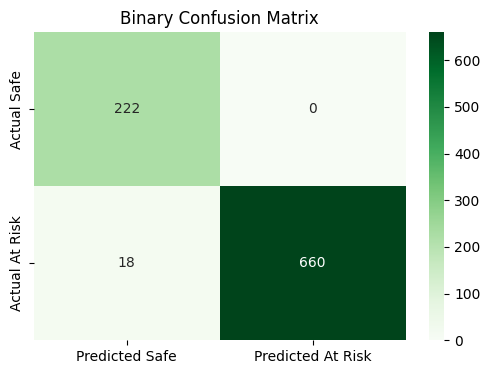

In [23]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Print Report
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'At Risk (1)']))

# Plot 2x2 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Safe', 'Predicted At Risk'],
            yticklabels=['Actual Safe', 'Actual At Risk'])
plt.title("Binary Confusion Matrix")
plt.show()

In [24]:
# 3. Extract the values directly from the 'cm' variable from the previous cell
tn, fp, fn, tp = cm.ravel()

# 4. Calculate Specificity
# Specificity = True Negatives / (True Negatives + False Positives)
specificity = tn / (tn + fp)

print("--- SPECIFICITY CALCULATION ---")
print(f"True Negatives (TN) extracted from matrix: {tn}")
print(f"False Positives (FP) extracted from matrix: {fp}")
print(f"Total Actual Negatives (TN + FP): {tn + fp}")
print(f"Calculated Specificity[TN/(TN+FP)]: {specificity:.4f} (or {specificity * 100:.2f}%)")

--- SPECIFICITY CALCULATION ---
True Negatives (TN) extracted from matrix: 222
False Positives (FP) extracted from matrix: 0
Total Actual Negatives (TN + FP): 222
Calculated Specificity[TN/(TN+FP)]: 1.0000 (or 100.00%)


In [25]:
total_errors = (y_test != y_pred).sum()
error_rate = (total_errors / len(y_test)) * 100

print(f"Total mistakes: {total_errors} out of {len(y_test)} samples")
print(f"Total Error Percentage: {error_rate:.2f}%")

Total mistakes: 18 out of 900 samples
Total Error Percentage: 2.00%


In [26]:
# Test on a specific row (e.g., row 10)
row_idx = 10
row_data = df.iloc[[row_idx]].copy()

# Prepare features
X_sample = row_data.drop(["Risk_Category", "Binary_Risk", "Job_Title"], axis=1)
for col, encoder in encoders.items():
    X_sample[col] = encoder.transform(X_sample[col])

# Scale and Predict
X_sample_scaled = scaler.transform(X_sample)
pred = model.predict(X_sample_scaled)[0]
prob = model.predict_proba(X_sample_scaled)[0][1]

print(f"Job Title      : {df.iloc[row_idx]['Job_Title']}")
print(f"Original Label : {df.iloc[row_idx]['Risk_Category']}")
print(f"Model Result   : {'At Risk' if pred == 1 else 'Safe'}")
print(f"Risk Probability: {prob:.2%}")

Job Title      : UX Researcher
Original Label : Medium
Model Result   : At Risk
Risk Probability: 98.28%


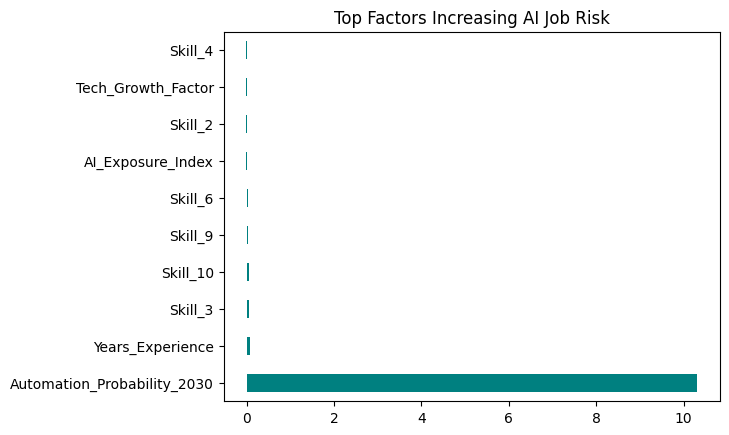

In [27]:
# Get model coefficients
importance = model.coef_[0]
feat_importances = pd.Series(importance, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top Factors Increasing AI Job Risk")
plt.show()

## Conclusion

This project successfully built a binary classifier to predict job loss risk using Logistic Regression.

### Key Performance Metrics
* **Overall Accuracy:** 98%
* **Specificity (True Negative Rate):** 1.0 (100%)
* **Recall (True Positive Rate):** 0.97 (97%)

### Interpretation
The model demonstrates exceptional performance, particularly in its specificity. A specificity of 1.0 means the model perfectly identified all 'Safe' jobs in the test set without a single false positive. In a real-world context, this ensures that employees or roles that are secure are not falsely flagged as being at risk.

While the model missed a small number of 'At Risk' instances (18 false negatives out of 900 samples), its ability to correctly identify the majority of high-risk cases (97% recall) makes it a highly reliable tool for this dataset.

### Next Steps
Given the extremely high accuracy, future work should include:
1. **Feature Importance Analysis:** Identifying which specific variables (e.g., Automation Probability, Tech Growth Factor) most strongly drive the 'At Risk' predictions.
2. **Overfitting Checks:** Testing the model on a completely new, external dataset to ensure these high metrics generalize well beyond the current data.